# 1. Objetivo

Este notebook cobre a etapa de **Construção e treinamento do modelo baseline** do Tech Challenge, dando sequência ao `02_preprocessamento_ml.ipynb`. Aqui vamos:

- reconstruir os dois cenários de modelagem (`referencia` e `comportamental`) e a divisão treino/teste, reutilizando exatamente as mesmas funções de `src/model_training.py` (sem duplicar lógica de preparação de dados);
- definir as métricas de avaliação do projeto (accuracy, F1-macro, classification_report e matriz de confusão), via `src/model_evaluation.py`;
- treinar um baseline de **Regressão Logística** para cada cenário, validado com validação cruzada estratificada (5 folds) antes de qualquer avaliação no conjunto de teste;
- treinar a pipeline final em `X_train`/`y_train` e avaliar em `X_test`/`y_test`;
- comparar os dois cenários lado a lado e concluir se a meta de 75% de acurácia exigida pelo desafio já é atingida no cenário `comportamental` (clinicamente relevante) ou depende de modelos mais robustos.

O cenário `referencia` (com `nr_altura`, `nr_peso` e `nr_imc`) segue funcionando como teto de performance e checagem de sanidade, já que o alvo é quase determinístico em função dessas colunas — não como o modelo que o hospital usaria na prática.

## 2. Importação das bibliotecas

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

sys.path.append("..")
from src.model_evaluation import avaliar_modelo
from src.model_training import (
    ORDEM_NIVEIS_OBESIDADE,
    RANDOM_STATE,
    TARGET,
    TEST_SIZE,
    carregar_dados_silver,
    criar_cenarios_modelagem,
    criar_pipeline,
    dividir_treino_teste,
    separar_features_target,
)

## 3. Configurações iniciais

Reutilizamos `RANDOM_STATE`, `TEST_SIZE` e `TARGET` de `src/model_training.py`, garantindo a mesma configuração usada no `02_preprocessamento_ml.ipynb`. Também definimos aqui `N_SPLITS_CV`, o número de folds da validação cruzada estratificada usada para estimar o baseline de forma mais robusta do que um único split de teste.

In [2]:
N_SPLITS_CV = 5

META_ACCURACY = 0.75

print(f"RANDOM_STATE: {RANDOM_STATE}")
print(f"TEST_SIZE: {TEST_SIZE}")
print(f"TARGET: {TARGET}")
print(f"N_SPLITS_CV: {N_SPLITS_CV}")
print(f"META_ACCURACY: {META_ACCURACY}")

pd.set_option("display.max_columns", None)
sns.set_theme(style="white")

RANDOM_STATE: 42
TEST_SIZE: 0.2
TARGET: ds_nivel_obesidade
N_SPLITS_CV: 5
META_ACCURACY: 0.75


## 4. Leitura e preparação dos dados

Reconstruímos aqui exatamente os mesmos passos do `02_preprocessamento_ml.ipynb`: carregar a camada Silver, separar `X`/`y`, criar os dois cenários de modelagem (`criar_cenarios_modelagem`) e dividir cada cenário em treino/teste (`dividir_treino_teste`), usando as mesmas funções de `src/model_training.py` — nenhuma lógica de preparação é reimplementada neste notebook.

In [3]:
dados_silver = carregar_dados_silver()

X, y = separar_features_target(dados_silver, target=TARGET)

cenarios = criar_cenarios_modelagem(X)

for nome_cenario, X_cenario in cenarios.items():
    print(f"Cenário '{nome_cenario}': {X_cenario.shape[1]} colunas -> {list(X_cenario.columns)}")

Cenário 'referencia': 20 colunas -> ['ds_genero', 'nr_idade', 'nr_altura', 'nr_peso', 'fl_historico_familiar_sobrepeso', 'fl_consumo_calorico_frequente', 'cd_consumo_de_vegetais', 'cd_numero_refeicoes_principais', 'ds_lanches_entre_refeicoes', 'fl_fumante', 'cd_consumo_agua', 'fl_monitora_calorias', 'cd_frequencia_atividade_fisica', 'cd_tempo_uso_eletronicos', 'ds_consumo_alcool', 'ds_meio_transporte', 'nr_imc', 'fl_transporte_ativo', 'ds_faixa_etaria', 'ds_consumo_alcool_agrupado']
Cenário 'comportamental': 17 colunas -> ['ds_genero', 'nr_idade', 'fl_historico_familiar_sobrepeso', 'fl_consumo_calorico_frequente', 'cd_consumo_de_vegetais', 'cd_numero_refeicoes_principais', 'ds_lanches_entre_refeicoes', 'fl_fumante', 'cd_consumo_agua', 'fl_monitora_calorias', 'cd_frequencia_atividade_fisica', 'cd_tempo_uso_eletronicos', 'ds_consumo_alcool', 'ds_meio_transporte', 'fl_transporte_ativo', 'ds_faixa_etaria', 'ds_consumo_alcool_agrupado']


In [4]:
splits = {}

for nome_cenario, X_cenario in cenarios.items():
    X_train, X_test, y_train, y_test = dividir_treino_teste(
        X_cenario,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    splits[nome_cenario] = (X_train, X_test, y_train, y_test)
    print(f"Cenário '{nome_cenario}': X_train {X_train.shape}, X_test {X_test.shape}")

Cenário 'referencia': X_train (1669, 20), X_test (418, 20)
Cenário 'comportamental': X_train (1669, 17), X_test (418, 17)


In [5]:
X_train_referencia, X_test_referencia, y_train_referencia, y_test_referencia = splits["referencia"]
X_train_comportamental, X_test_comportamental, y_train_comportamental, y_test_comportamental = splits["comportamental"]

assert X_train_referencia.index.equals(X_train_comportamental.index), (
    "Os índices de treino divergem entre os cenários — a comparação entre os modelos não seria justa."
)
assert X_test_referencia.index.equals(X_test_comportamental.index), (
    "Os índices de teste divergem entre os cenários — a comparação entre os modelos não seria justa."
)

print("Confirmado: os cenários 'referencia' e 'comportamental' caíram exatamente na mesma divisão de linhas em treino/teste.")

Confirmado: os cenários 'referencia' e 'comportamental' caíram exatamente na mesma divisão de linhas em treino/teste.


## 5. Definição das métricas de avaliação

Como este é um problema de classificação **multiclasse** (7 níveis de obesidade), a acurácia sozinha não é suficiente — ela pode mascarar mau desempenho em classes minoritárias. Por isso, seguimos a metodologia do projeto e reportamos sempre:

- **accuracy**: proporção de acertos no geral;
- **F1-macro**: média do F1-score calculado por classe, sem ponderar pelo tamanho da classe — penaliza modelos que só acertam as classes majoritárias;
- **classification_report**: precision, recall e F1 detalhados por classe;
- **matriz de confusão**: onde estão concentrados os erros (ex.: confusão entre níveis adjacentes de obesidade).

Essas quatro métricas são calculadas por `avaliar_modelo()` (`src/model_evaluation.py`), reutilizada de forma idêntica para os dois cenários e, futuramente, para qualquer modelo testado no `04_comparacao_modelos.ipynb`.

Antes de avaliar no conjunto de teste, também rodamos uma **validação cruzada estratificada** (`StratifiedKFold`, `N_SPLITS_CV` folds) sobre `X_train`/`y_train` de cada cenário. Isso dá uma estimativa mais robusta do desempenho do baseline do que um único split treino/teste, além de permitir observar a variabilidade (desvio-padrão) entre folds — um único split pode ser otimista ou pessimista por acaso.

In [6]:
validacao_cruzada = StratifiedKFold(
    n_splits=N_SPLITS_CV,
    shuffle=True,
    random_state=RANDOM_STATE,
)

METRICAS_CV = ["accuracy", "f1_macro"]

print(f"Validação cruzada: {N_SPLITS_CV} folds, métricas {METRICAS_CV}")

Validação cruzada: 5 folds, métricas ['accuracy', 'f1_macro']


## 6. Treinamento do baseline

Para cada cenário, construímos a pipeline completa com `criar_pipeline(X_train_cenario, LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))` — o pré-processador é ajustado dentro da própria pipeline, então cada fold da validação cruzada reajusta o `ColumnTransformer` apenas com os dados daquele fold, sem vazamento de informação.

### 6.1 Validação cruzada estratificada (5 folds) sobre o treino

In [7]:
resultados_cv = {}

for nome_cenario, (X_train_cenario, _, y_train_cenario, _) in splits.items():
    pipeline_cenario = criar_pipeline(
        X_train_cenario,
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    )

    scores_cv = cross_validate(
        pipeline_cenario,
        X_train_cenario,
        y_train_cenario,
        cv=validacao_cruzada,
        scoring=METRICAS_CV,
    )

    resultados_cv[nome_cenario] = scores_cv

    print(f"Cenário '{nome_cenario}':")
    print(
        f"  Accuracy (CV): {scores_cv['test_accuracy'].mean():.4f} "
        f"± {scores_cv['test_accuracy'].std():.4f}"
    )
    print(
        f"  F1-macro (CV): {scores_cv['test_f1_macro'].mean():.4f} "
        f"± {scores_cv['test_f1_macro'].std():.4f}"
    )

Cenário 'referencia':
  Accuracy (CV): 0.8993 ± 0.0227
  F1-macro (CV): 0.8948 ± 0.0239
Cenário 'comportamental':
  Accuracy (CV): 0.6075 ± 0.0326
  F1-macro (CV): 0.5817 ± 0.0353


### 6.2 Treinamento final e avaliação no conjunto de teste

Com a estimativa da validação cruzada em mãos, treinamos a pipeline final de cada cenário em todo o `X_train`/`y_train` e avaliamos uma única vez no `X_test`/`y_test`, reservado desde o `02_preprocessamento_ml.ipynb` e não utilizado em nenhuma etapa de ajuste até aqui.

In [8]:
pipelines_finais = {}
resultados_teste = {}

for nome_cenario, (X_train_cenario, X_test_cenario, y_train_cenario, y_test_cenario) in splits.items():
    pipeline_final = criar_pipeline(
        X_train_cenario,
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    )
    pipeline_final.fit(X_train_cenario, y_train_cenario)

    pipelines_finais[nome_cenario] = pipeline_final

    resultado = avaliar_modelo(
        pipeline_final,
        X_test_cenario,
        y_test_cenario,
        labels=ORDEM_NIVEIS_OBESIDADE,
    )
    resultados_teste[nome_cenario] = resultado

    print(f"\n{'=' * 60}")
    print(f"Cenário '{nome_cenario}' — desempenho no conjunto de teste")
    print(f"{'=' * 60}")
    print(f"Accuracy: {resultado['accuracy']:.4f}")
    print(f"F1-macro: {resultado['f1_macro']:.4f}")
    print("\nClassification report:")
    print(resultado["classification_report"])


Cenário 'referencia' — desempenho no conjunto de teste
Accuracy: 0.9187
F1-macro: 0.9152

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      1.00      0.95        53
      Normal_Weight       0.90      0.79      0.84        57
 Overweight_Level_I       0.82      0.85      0.84        55
Overweight_Level_II       0.89      0.86      0.88        58
     Obesity_Type_I       0.96      0.93      0.94        70
    Obesity_Type_II       0.95      1.00      0.98        60
   Obesity_Type_III       0.98      0.98      0.98        65

           accuracy                           0.92       418
          macro avg       0.92      0.92      0.92       418
       weighted avg       0.92      0.92      0.92       418


Cenário 'comportamental' — desempenho no conjunto de teste
Accuracy: 0.6220
F1-macro: 0.5881

Classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.61  

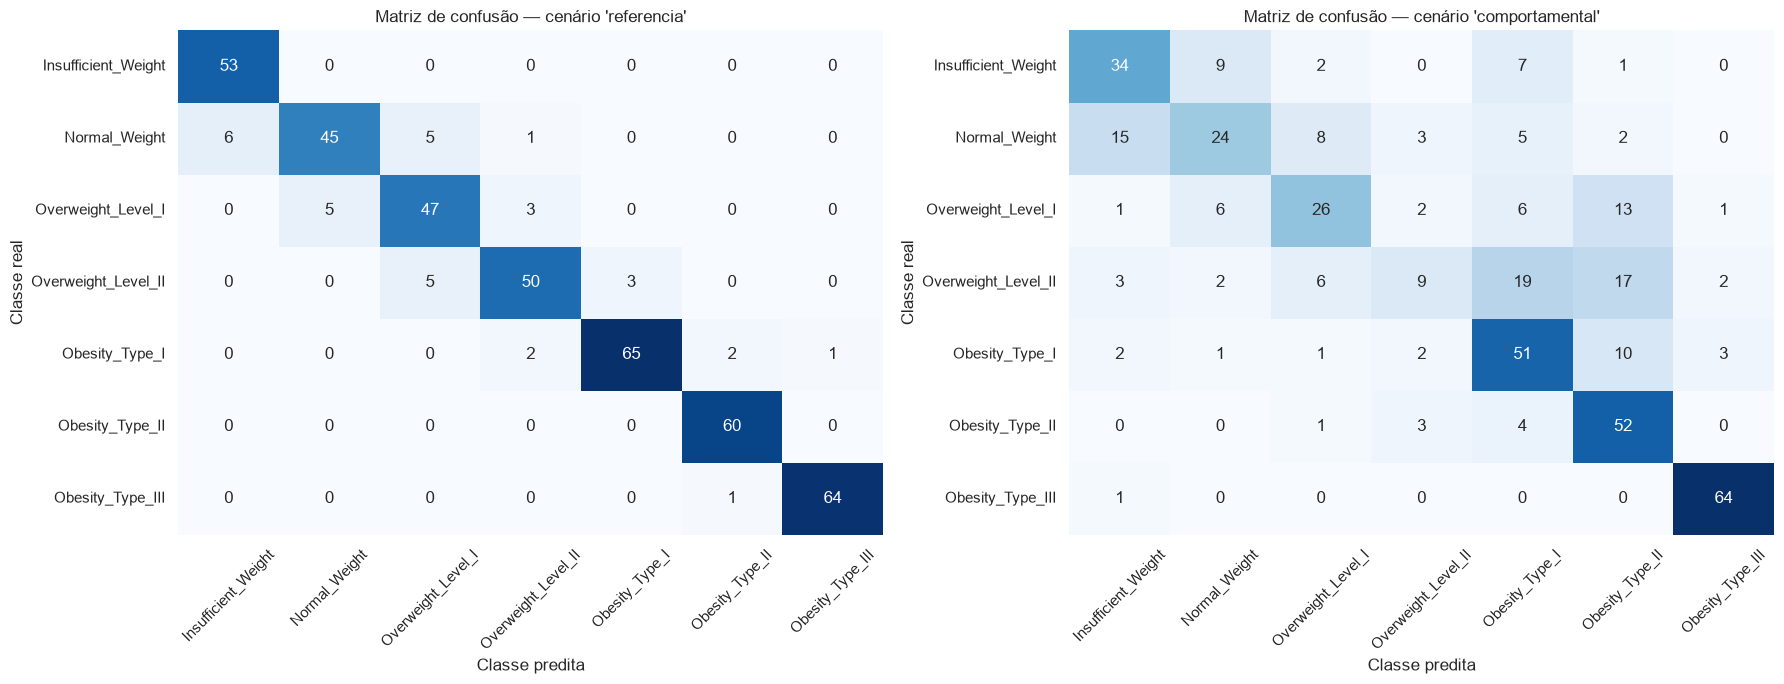

In [9]:
rotulos_classes = ORDEM_NIVEIS_OBESIDADE

fig, eixos = plt.subplots(1, 2, figsize=(18, 7))

for eixo, nome_cenario in zip(eixos, resultados_teste):
    matriz_confusao = resultados_teste[nome_cenario]["matriz_confusao"]

    sns.heatmap(
        matriz_confusao,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=rotulos_classes,
        yticklabels=rotulos_classes,
        cbar=False,
        ax=eixo,
    )
    eixo.set_title(f"Matriz de confusão — cenário '{nome_cenario}'")
    eixo.set_xlabel("Classe predita")
    eixo.set_ylabel("Classe real")
    eixo.tick_params(axis="x", rotation=45)
    eixo.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## 7. Comparação entre cenários

Consolidamos as métricas de validação cruzada (média ± desvio-padrão) e de teste dos dois cenários em uma única tabela, junto com a checagem explícita da meta de 75% de acurácia exigida pelo desafio.

In [10]:
tabela_comparativa = pd.DataFrame(
    {
        "Cenário": list(resultados_cv.keys()),
        "Accuracy CV (média)": [
            resultados_cv[cenario]["test_accuracy"].mean() for cenario in resultados_cv
        ],
        "Accuracy CV (desvio-padrão)": [
            resultados_cv[cenario]["test_accuracy"].std() for cenario in resultados_cv
        ],
        "F1-macro CV (média)": [
            resultados_cv[cenario]["test_f1_macro"].mean() for cenario in resultados_cv
        ],
        "F1-macro CV (desvio-padrão)": [
            resultados_cv[cenario]["test_f1_macro"].std() for cenario in resultados_cv
        ],
        "Accuracy teste": [
            resultados_teste[cenario]["accuracy"] for cenario in resultados_cv
        ],
        "F1-macro teste": [
            resultados_teste[cenario]["f1_macro"] for cenario in resultados_cv
        ],
    }
)

tabela_comparativa["Atinge meta de 75% de accuracy (teste)?"] = (
    tabela_comparativa["Accuracy teste"] >= META_ACCURACY
)

tabela_comparativa.round(4)

,Cenário,Accuracy CV (média),Accuracy CV (desvio-padrão),F1-macro CV (média),F1-macro CV (desvio-padrão),Accuracy teste,F1-macro teste,Atinge meta de 75% de accuracy (teste)?
0,referencia,0.8993,0.0227,0.8948,0.0239,0.9187,0.9152,True
1,comportamental,0.6075,0.0326,0.5817,0.0353,0.6220,0.5881,False


Para checar indícios de overfitting, comparamos também a accuracy da pipeline final no próprio `X_train` (desempenho "otimista", pois o modelo já viu esses dados) com a accuracy da validação cruzada (estimativa em dados não vistos dentro do treino) e a accuracy no teste (dados nunca vistos). Uma diferença grande entre a accuracy de treino e as demais indicaria que o modelo está memorizando o treino em vez de generalizar.

In [11]:
tabela_overfitting = pd.DataFrame(
    {
        "Cenário": list(splits.keys()),
        "Accuracy treino (in-sample)": [
            pipelines_finais[nome_cenario].score(splits[nome_cenario][0], splits[nome_cenario][2])
            for nome_cenario in splits
        ],
        "Accuracy CV (média)": [
            resultados_cv[nome_cenario]["test_accuracy"].mean() for nome_cenario in splits
        ],
        "Accuracy teste": [
            resultados_teste[nome_cenario]["accuracy"] for nome_cenario in splits
        ],
    }
)

tabela_overfitting["Gap treino - teste"] = (
    tabela_overfitting["Accuracy treino (in-sample)"] - tabela_overfitting["Accuracy teste"]
)

tabela_overfitting.round(4)

,Cenário,Accuracy treino (in-sample),Accuracy CV (média),Accuracy teste,Gap treino - teste
0,referencia,0.9341,0.8993,0.9187,0.0154
1,comportamental,0.6291,0.6075,0.6220,0.0071


## 8. Conclusões

- **Cenário `referencia`** (com `nr_altura`, `nr_peso` e `nr_imc`): accuracy de 89,9% ± 2,3% na validação cruzada e 91,9% no teste (F1-macro de 91,5%). Confirma-se a hipótese: como o alvo é quase determinístico em função de peso/altura/IMC, o teto de performance é alto e a pipeline de pré-processamento e modelagem está correta (checagem de sanidade). Ainda assim, **não é o modelo que o hospital usaria na prática**, já que reaprender a fórmula do IMC não agrega valor clínico sobre o que o paciente já sabe (seu próprio peso e altura).
- **Cenário `comportamental`** (sem métricas antropométricas): accuracy de apenas 60,8% ± 3,3% na validação cruzada e 62,2% no teste (F1-macro de 58,8%). É o cenário clinicamente relevante — representa o que o modelo consegue prever a partir apenas de hábitos alimentares, atividade física e dados demográficos —, mas **ainda não atinge a meta de 75% de acurácia exigida pelo desafio**. A matriz de confusão e o classification_report mostram que o erro se concentra sobretudo nas classes intermediárias (`Normal_Weight`, `Overweight_Level_I`, `Overweight_Level_II`), enquanto o extremo `Obesity_Type_III` é bem separado mesmo sem dados antropométricos.
- **Baseline oficial do projeto**: o baseline que estabelece a referência para os modelos mais robustos do `04_comparacao_modelos.ipynb` é o cenário **`comportamental`** com Regressão Logística (accuracy de teste: 62,2%; F1-macro: 58,8%) — é ele que precisa ser superado por algoritmos mais sofisticados, já que é o cenário alinhado ao objetivo de negócio. O cenário `referencia` permanece apenas como teto de performance/checagem de sanidade, não como candidato a modelo de produção.
- **Meta de 75% de accuracy**: com este baseline simples, a meta **não é atingida** usando apenas hábitos de vida (62,2% < 75%). Ou seja, a meta do desafio **depende de modelos mais robustos** (árvores, ensembles) e/ou de engenharia de features adicional, a serem avaliados no `04_comparacao_modelos.ipynb` — o cenário `referencia` cumpre a meta numericamente (91,9%), mas não deve ser usado para "fechar" o requisito do desafio, por não ter valor clínico incremental.
- **Overfitting**: o gap entre a accuracy in-sample (treino) e a accuracy de teste foi pequeno nos dois cenários (1,5 p.p. em `referencia`, 0,7 p.p. em `comportamental`), e a accuracy de teste ficou próxima da média da validação cruzada em ambos os casos. Isso indica que a Regressão Logística, sendo um modelo linear de baixa complexidade, generaliza bem para os dois cenários — não há sinal de memorização do conjunto de treino. O desempenho baixo do cenário `comportamental` é, portanto, uma limitação de capacidade preditiva das variáveis comportamentais disponíveis (underfitting/insuficiência de sinal), não overfitting.

Próximo passo (`04_comparacao_modelos.ipynb`): testar múltiplos algoritmos (além da Regressão Logística) nos dois cenários, usando a mesma validação cruzada estratificada e as mesmas funções de `src/model_training.py` e `src/model_evaluation.py`, com foco em fechar a distância até os 75% de accuracy no cenário `comportamental`.